# Hawkes III：スパイク規模で減衰時間が変わるモデル

Hawkes IIIでは大きなスパイクほど影響が長く残る。

$$\tau_d=\tau_0\left(1-\exp(-x_d/x_{0,d})\right)$$

イベント $i$ のday $d$への寄与は $\gamma\exp(-(d-i)/\tau_i)$。イベントごとに $\tau_i$ が異なるので、Hawkes Iと同じ単一状態の再帰式にはしない。

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside jepx-data-analytics.")
PROJECT_DIR = (
    REPO_ROOT
    / "A_Hawkes_Model_Approach_to_Modeling_Price_Spikes_in_the_Japanese_Electricity_Market"
)
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

AREA = "Tokyo"
TIME_CODE = 15
DATA_DIR = PROJECT_DATA_DIR / "processed"
u_wide = pd.read_csv(
    DATA_DIR / "u_dict" / f"u_{AREA}.csv", index_col=0, parse_dates=True
)
x_wide = pd.read_csv(
    DATA_DIR / "x_dict" / f"x_{AREA}.csv", index_col=0, parse_dates=True
)
data = pd.DataFrame({
    "u": u_wide[str(TIME_CODE)].astype(int),
    "x": x_wide[str(TIME_CODE)].astype(float),
})
data = data.loc["2016-04-01":"2022-03-31"].dropna()
data.describe()

,u,x
count,2191.000000,2191.000000
mean,0.053400,1.561824
std,0.224882,12.168132
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,177.000000


## 強度の直接計算

$$\lambda_d^-=\mu+\sum_{i<d}u_i\gamma\exp(-(d-i)/\tau_i)$$

当日の $u_d$ は当日の予測強度に含めず、未来日のみに寄与させる。

In [2]:
EPS = 1e-8


def running_spike_mean(x):
    x = np.asarray(x, float)
    hit = x > 0
    n = np.cumsum(hit)
    total = np.cumsum(x)
    fallback = x[hit].mean() if hit.any() else 1.0
    return np.divide(total, n, out=np.full_like(x, fallback), where=n > 0)


def hawkes3_intensity(u, x, mu, tau0, gamma):
    u = np.asarray(u, int)
    x = np.asarray(x, float)
    x0 = running_spike_mean(x)
    tau_i = tau0 * (1 - np.exp(-x / np.maximum(x0, EPS)))
    pred = np.full(len(u), mu, float)
    for i in np.flatnonzero(u):
        if i + 1 < len(u):
            lag = np.arange(1, len(u) - i, dtype=float)
            pred[i + 1 :] += gamma * np.exp(-lag / max(tau_i[i], EPS))
    return np.clip(pred, EPS, 1 - EPS), tau_i


lam_demo, tau_demo = hawkes3_intensity(data.u, data.x, mu=0.01, tau0=10, gamma=0.3)
pd.DataFrame({
    "u": data.u,
    "x": data.x,
    "tau_i": tau_demo,
    "lambda_pred": lam_demo,
}).tail()

,u,x,tau_i,lambda_pred
date,,,,
2022-03-27,0,0.00,0.000000,1.000000
2022-03-28,0,0.00,0.000000,0.853373
2022-03-29,1,2.24,0.737284,0.683905
2022-03-30,0,0.00,0.000000,0.633834
2022-03-31,0,0.00,0.000000,0.478944


## パラメータ推定

Hawkes IIと同様、モデル部分を検証しやすいMAP基準実装とする。$\mu,\tau_0,\gamma>0$ は対数パラメータ化で保証する。

In [3]:
def fit_hawkes3(u, x):
    u = np.asarray(u, int)
    x = np.asarray(x, float)
    theta0 = np.log([max(u.mean(), 1e-3), 10.0, 0.2])

    def objective(theta):
        mu, tau0, gamma = np.exp(theta)
        lam, _ = hawkes3_intensity(u, x, mu, tau0, gamma)
        nll = -np.sum(u * np.log(lam) + (1 - u) * np.log(1 - lam))
        return nll + 0.5 * np.sum(((theta - theta0) / 2) ** 2)

    opt = minimize(
        objective, theta0, method="L-BFGS-B", bounds=[(-9, -0.01), (-4, 6), (-9, -0.01)]
    )
    mu, tau0, gamma = np.exp(opt.x)
    return {
        "mu": mu,
        "tau0": tau0,
        "gamma": gamma,
        "objective": opt.fun,
        "success": opt.success,
    }


fit3 = fit_hawkes3(data.u, data.x)
fit3

{'mu': 0.006176470954284996,
 'tau0': 8.017888641449163,
 'gamma': 0.20917685348053883,
 'objective': 236.7040927580615,
 'success': True}

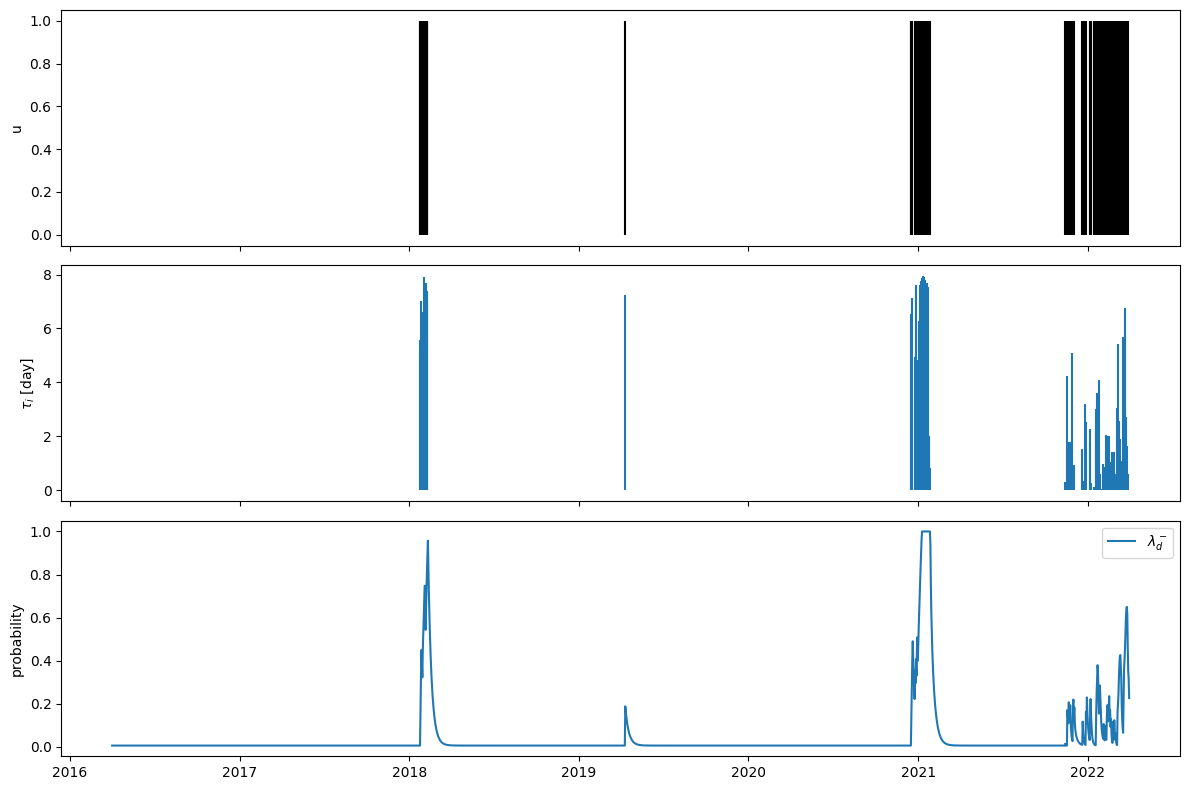

In [4]:
lambda3, tau3 = hawkes3_intensity(
    data.u, data.x, fit3["mu"], fit3["tau0"], fit3["gamma"]
)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].vlines(data.index[data.u.eq(1)], 0, 1, color="black")
axes[0].set_ylabel("u")
axes[1].vlines(data.index, 0, tau3)
axes[1].set_ylabel(r"$\tau_i$ [day]")
axes[2].plot(data.index, lambda3, label=r"$\lambda_d^-$")
axes[2].set_ylabel("probability")
axes[2].legend()
plt.tight_layout()